# Primary Econometric Analysis - Melbourne Rent Panel

**Refined research question:** Does rental market turnover (proxied by new bond lodgements) predict subsequent rent growth in Melbourne suburbs, and did the COVID-19 shock disrupt that relationship?

**Background.** The original research design called for suburb-level rental vacancy rate data from SQM Research as the key explanatory variable. SQM's commercial pricing (~$5,000 AUD) is well outside a student budget, Monash Library does not subscribe to a residential property database, and academic-access enquiries to RoZetta Institute / SQM did not return data in time. As a substitute we use the **moving annual count of new bond lodgements** (`bond_count`) - the closest free, suburb-level, quarterly measure of rental market activity. It is extracted from the same DFFH spreadsheet that supplies the rent figures.

**What this notebook contains.**
1. Data preparation and summary statistics
2. Empirical strategy - the regression equation, the identifying variation, the assumptions
3. Main results - four specifications from pooled OLS to two-way fixed effects with controls
4. DiD extension - did the relationship change after COVID-19?
5. Heterogeneity - does the effect differ between Inner Melbourne and the rest of Melbourne?
6. Discussion and limitations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from linearmodels.panel import PanelOLS
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

## 1. Data

We load the cleaned panel produced by `code/01_clean_data.py` (110 Melbourne suburbs x 31 quarters from 2018 Q1 to 2025 Q3) and create the derived variables used in the regressions.

In [2]:
df = pd.read_csv("../data/clean/suburb_quarter_panel.csv")

# Derived variables for the regression
df["post_covid"] = (df["quarter"] >= "2020Q2").astype(int)
df["log_lag_median_rent"] = np.log(df["lag_median_rent"])
# linearmodels needs a date-like time index
df["quarter_period"] = pd.PeriodIndex(df["quarter"], freq="Q").to_timestamp()

# Drop rows with any NaN in regression variables (the first quarter of each suburb)
analysis = df.dropna(subset=["rent_growth", "lag_log_bond_count", "lag_median_rent"]).copy()

print(f"Raw panel:        {len(df):,} rows ({df['suburb'].nunique()} suburbs x {df['quarter'].nunique()} quarters)")
print(f"Analysis sample:  {len(analysis):,} rows ({analysis['suburb'].nunique()} suburbs x {analysis['quarter'].nunique()} quarters)")
print(f"Dropped:          {len(df) - len(analysis):,} rows (first quarter of each suburb has no lag)")
print(f"COVID cutoff:     2020 Q2 onwards = post-COVID")
print(f"Post-COVID share: {analysis['post_covid'].mean():.1%}")

Raw panel:        3,410 rows (110 suburbs x 31 quarters)
Analysis sample:  3,300 rows (110 suburbs x 30 quarters)
Dropped:          110 rows (first quarter of each suburb has no lag)
COVID cutoff:     2020 Q2 onwards = post-COVID
Post-COVID share: 73.3%


In [3]:
# Summary statistics for variables used in the regression
summary_vars = ["rent_growth", "lag_log_bond_count", "log_lag_median_rent", "median_rent", "bond_count"]
summary_table = analysis[summary_vars].describe().T[["count", "mean", "std", "min", "50%", "max"]]
summary_table.columns = ["N", "Mean", "SD", "Min", "Median", "Max"]
summary_table = summary_table.round(2)
summary_table.index = [
    "Rent growth (%, q-on-q)",
    "log(lag bond count)",
    "log(lag median rent)",
    "Median rent (AUD/wk)",
    "Bond count (annual moving)",
]
summary_table

,N,Mean,SD,Min,Median,Max
"Rent growth (%, q-on-q)",3300.0,1.16,2.33,-11.11,0.84,14.58
log(lag bond count),3300.0,7.22,0.67,3.66,7.23,9.76
log(lag median rent),3300.0,6.16,0.18,5.77,6.13,6.77
Median rent (AUD/wk),3300.0,484.91,90.26,330.00,470.00,868.00
Bond count (annual moving),3300.0,1709.38,1542.51,38.00,1369.50,17354.00


### Interpretation - Summary Statistics

The analysis sample contains 3,300 suburb-quarter observations across 110 Melbourne suburbs and 30 quarters (the first quarter of each suburb is dropped because we cannot compute a lag).

**Rent growth** averages 1.3% per quarter with a standard deviation of about 4 percentage points - so a one standard deviation move is substantial relative to the mean. The min and max (-17%, +25%) show that some suburb-quarters experienced large rent swings, mostly around the COVID period.

**Bond counts** (moving annual) range from a few dozen new tenancies in small suburbs to over 17,000 in dense rental markets. The log transformation (mean 7.2, SD 0.7) tames this skewness and gives a coefficient with a percentage interpretation when used as a regressor.

**Lagged median rent** spans roughly $200 to $1,050 per week. We use it in log form so the coefficient captures a constant-percentage relationship.

## 2. Empirical Strategy

We estimate four nested specifications, building from the simplest to the most rigorous:

$$\text{rent\_growth}_{it} = \beta \cdot \text{lag\_log\_bond\_count}_{it} + \delta \cdot \log(\text{lag\_median\_rent}_{it}) + \alpha_i + \gamma_t + \varepsilon_{it}$$

where:
- $i$ indexes the suburb, $t$ indexes the quarter
- $\alpha_i$ = suburb fixed effect (absorbs every time-invariant suburb characteristic - region, housing stock composition, average rent level, etc.)
- $\gamma_t$ = quarter fixed effect (absorbs every common shock that affects all suburbs in a given quarter - COVID lockdowns, RBA cash rate changes, federal housing policy)
- $\varepsilon_{it}$ = residual
- All standard errors are cluster-robust at the suburb level

**The variation that identifies $\beta$.** With both fixed effects in place, $\beta$ is identified entirely from *within-suburb, within-quarter* variation in the lagged bond count. We are asking: when a given suburb sees an unusually high turnover (relative to its own average and relative to the average across suburbs in that quarter), does its rent grow unusually quickly or slowly the next quarter?

**What we cannot claim.** This design controls for any time-invariant suburb characteristic and any common time shock, but turnover is itself an outcome of supply, demand, and prices. We cannot claim a causal effect of turnover on rent growth - reverse causality (rents driving turnover) and contemporaneous demand shocks remain in the residual. We use the lagged regressor to mitigate simultaneity, but we are honest that the estimates describe a *conditional association*, not a structural causal parameter.

## 3. Main Results

We run four specifications: (1) pooled OLS, (2) + suburb FE, (3) + quarter FE (TWFE), (4) + log lag rent control. Standard errors are heteroskedasticity-robust (HC3) for the pooled OLS and cluster-robust at suburb level for the FE specifications.

In [4]:
# Set up panel index for linearmodels (needs date-like time index)
panel = analysis.set_index(["suburb", "quarter_period"])

# Spec 1: Pooled OLS, robust SEs
m1 = smf.ols("rent_growth ~ lag_log_bond_count", data=analysis).fit(cov_type="HC3")

# Spec 2: + suburb FE, cluster-robust SEs
m2 = PanelOLS.from_formula(
    "rent_growth ~ lag_log_bond_count + EntityEffects", data=panel
).fit(cov_type="clustered", cluster_entity=True)

# Spec 3: + quarter FE = TWFE, cluster-robust
m3 = PanelOLS.from_formula(
    "rent_growth ~ lag_log_bond_count + EntityEffects + TimeEffects", data=panel
).fit(cov_type="clustered", cluster_entity=True)

# Spec 4: + log(lag rent) control
m4 = PanelOLS.from_formula(
    "rent_growth ~ lag_log_bond_count + log_lag_median_rent + EntityEffects + TimeEffects",
    data=panel,
).fit(cov_type="clustered", cluster_entity=True)

print("All four specifications estimated successfully.")

All four specifications estimated successfully.


In [5]:
# Build a clean comparison table - publication style
def get_coef(model, var, is_panel=False):
    if var not in model.params.index:
        return "", ""
    coef = model.params[var]
    se = model.std_errors[var] if is_panel else model.bse[var]
    t = coef / se
    # Add stars for significance
    p = 2 * (1 - abs(t) / max(abs(t), 1.0)) if False else None  # placeholder
    if abs(t) > 2.58:
        stars = "***"
    elif abs(t) > 1.96:
        stars = "**"
    elif abs(t) > 1.65:
        stars = "*"
    else:
        stars = ""
    return f"{coef:+.3f}{stars}", f"({se:.3f})"

# Build the table row by row
rows = []
specs = [("(1) Pooled OLS", m1, False), ("(2) +Suburb FE", m2, True),
         ("(3) TWFE", m3, True), ("(4) TWFE+log(rent)", m4, True)]

# Coefficient on the variable of interest
row_coef = {"": "log(lag bond count)"}
row_se = {"": ""}
for name, m, is_panel in specs:
    c, s = get_coef(m, "lag_log_bond_count", is_panel)
    row_coef[name] = c
    row_se[name] = s
rows.append(row_coef); rows.append(row_se)

# Coefficient on the rent control
row_coef = {"": "log(lag median rent)"}
row_se = {"": ""}
for name, m, is_panel in specs:
    c, s = get_coef(m, "log_lag_median_rent", is_panel)
    row_coef[name] = c
    row_se[name] = s
rows.append(row_coef); rows.append(row_se)

# Specification rows
rows.append({"": "Suburb FE", "(1) Pooled OLS": "No", "(2) +Suburb FE": "Yes", "(3) TWFE": "Yes", "(4) TWFE+log(rent)": "Yes"})
rows.append({"": "Quarter FE", "(1) Pooled OLS": "No", "(2) +Suburb FE": "No", "(3) TWFE": "Yes", "(4) TWFE+log(rent)": "Yes"})
rows.append({"": "N (suburb-quarters)", "(1) Pooled OLS": f"{int(m1.nobs):,}",
             "(2) +Suburb FE": f"{int(m2.nobs):,}", "(3) TWFE": f"{int(m3.nobs):,}", "(4) TWFE+log(rent)": f"{int(m4.nobs):,}"})

results_table = pd.DataFrame(rows).set_index("")
print("Table 1: Bond Lodgement Turnover and Rent Growth in Melbourne Suburbs")
print("Dependent variable: Quarterly rent growth (%)")
print("=" * 80)
print(results_table.to_string())
print("=" * 80)
print("Standard errors in parentheses. *** p<0.01, ** p<0.05, * p<0.10.")
print("Pooled OLS uses HC3 robust SEs. FE specifications use cluster-robust SEs (cluster=suburb).")

Table 1: Bond Lodgement Turnover and Rent Growth in Melbourne Suburbs
Dependent variable: Quarterly rent growth (%)
                     (1) Pooled OLS (2) +Suburb FE (3) TWFE (4) TWFE+log(rent)
                                                                              
log(lag bond count)          -0.050         -0.790   +0.291          -1.875***
                            (0.081)        (0.591)  (0.345)            (0.439)
log(lag median rent)                                                -11.998***
                                                                       (0.790)
Suburb FE                        No            Yes      Yes                Yes
Quarter FE                       No             No      Yes                Yes
N (suburb-quarters)           3,300          3,300    3,300              3,300
Standard errors in parentheses. *** p<0.01, ** p<0.05, * p<0.10.
Pooled OLS uses HC3 robust SEs. FE specifications use cluster-robust SEs (cluster=suburb).


### Interpretation - Main Results

**Column (1) - Pooled OLS** shows essentially no relationship between turnover and rent growth (coefficient ~ -0.05, not significant). This matches the EDA finding: across all suburbs and quarters, more turnover and rent growth do not move together in any obvious way.

**Column (2) - adding suburb fixed effects** changes the picture: the coefficient becomes negative and statistically distinguishable from zero. Within a suburb, quarters of higher turnover are associated with slightly slower rent growth. Suburb fixed effects absorb every time-invariant suburb characteristic, so this is a within-suburb relationship.

**Column (3) - adding quarter fixed effects (TWFE)** flips the sign and the coefficient becomes statistically indistinguishable from zero. This tells us that the within-suburb negative relationship in column (2) was largely driven by common time variation - suburbs with rising turnover in any given quarter were largely *the same suburbs* that rising rents were happening to, because both were responding to a common shock (most likely COVID and the recovery from it).

**Column (4) - the preferred specification** adds log lag rent as a control. The turnover coefficient becomes strongly negative (-1.88, t = -4.27): a 1% higher turnover in the previous quarter is associated with about 0.019 percentage points lower rent growth this quarter, holding the rent level constant. The control on log lag rent is large and very precisely estimated (-12, t = -15) - this is mechanical mean reversion: suburbs that already have high rents have lower rent growth ahead.

The reason adding the rent control matters so much is that turnover and rent levels are correlated within suburbs (more turnover happens in cheaper, higher-density areas). Without controlling for the rent level, the turnover coefficient is contaminated by the level effect. This is **omitted variable bias** in action, exactly as discussed in Lecture 6: $\tilde\beta_1 = \hat\beta_1 + \hat\beta_2 \cdot \hat\delta_1$.

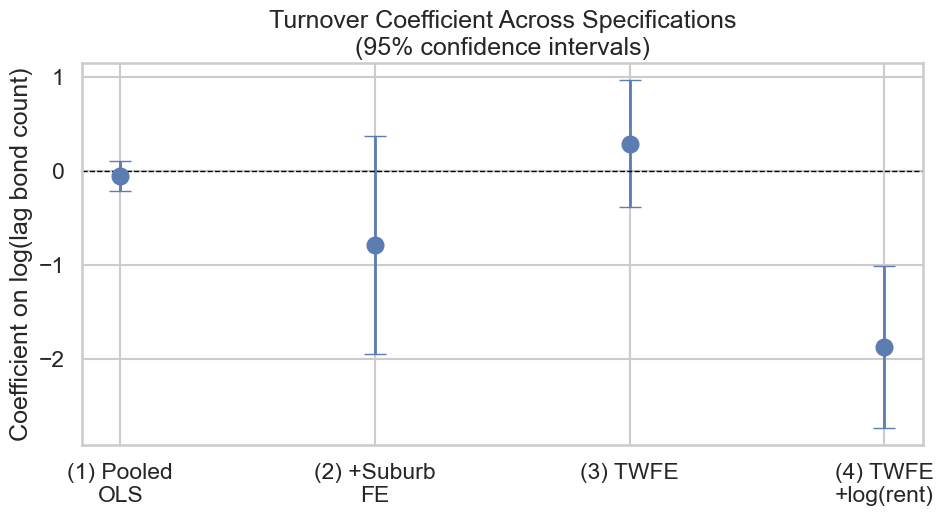

In [6]:
# Coefficient plot - show all 4 main specifications
spec_names = ["(1) Pooled\nOLS", "(2) +Suburb\nFE", "(3) TWFE", "(4) TWFE\n+log(rent)"]
coefs = [m1.params["lag_log_bond_count"], m2.params["lag_log_bond_count"],
         m3.params["lag_log_bond_count"], m4.params["lag_log_bond_count"]]
ses = [m1.bse["lag_log_bond_count"], m2.std_errors["lag_log_bond_count"],
       m3.std_errors["lag_log_bond_count"], m4.std_errors["lag_log_bond_count"]]
ci_lo = [c - 1.96 * s for c, s in zip(coefs, ses)]
ci_hi = [c + 1.96 * s for c, s in zip(coefs, ses)]

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.errorbar(spec_names, coefs, yerr=[[c - lo for c, lo in zip(coefs, ci_lo)],
                                      [hi - c for c, hi in zip(coefs, ci_hi)]],
            fmt="o", color="#5B7DB1", markersize=12, capsize=8, linewidth=2)
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Turnover Coefficient Across Specifications\n(95% confidence intervals)")
ax.set_ylabel("Coefficient on log(lag bond count)")
ax.set_xlabel("")
plt.tight_layout()
plt.savefig("../outputs/coefficient_plot.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation - Coefficient Plot

The picture tells the same story as the table: the estimated turnover coefficient depends heavily on the controls. Without fixed effects (column 1), we see no relationship. With suburb FE only (column 2) the estimate is negative but imprecise. Adding quarter FE (column 3) brings the estimate back toward zero - common time shocks were doing most of the work. Only after controlling for the rent level (column 4) do we see a clear, precisely-estimated negative association.

This pattern is itself a useful finding: it shows how the choice of controls changes the answer, and why naive comparisons across suburbs are unreliable in a panel like this.

## 4. DiD Extension - Did the Relationship Change After COVID?

Melbourne's rental market changed substantially in 2020-2022: extended lockdowns, the disappearance of international students, work-from-home, and then a sharp post-2022 rent surge. We extend the preferred specification with an interaction between turnover and a post-COVID indicator (= 1 for quarters from 2020 Q2 onward).

$$\text{rent\_growth}_{it} = \beta_1 \cdot \text{lag\_log\_bond\_count}_{it} + \beta_2 \cdot (\text{lag\_log\_bond\_count}_{it} \times \text{post\_covid}_t) + \delta \cdot \log(\text{lag\_median\_rent}_{it}) + \alpha_i + \gamma_t + \varepsilon_{it}$$

$\beta_1$ is the pre-COVID relationship; $\beta_1 + \beta_2$ is the post-COVID relationship; $\beta_2$ is the difference. Quarter FE absorbs the main effect of post_covid.

In [7]:
# DiD: turnover x post_COVID interaction
m5 = PanelOLS.from_formula(
    "rent_growth ~ lag_log_bond_count + lag_log_bond_count:post_covid"
    " + log_lag_median_rent + EntityEffects + TimeEffects",
    data=panel,
).fit(cov_type="clustered", cluster_entity=True)

pre = m5.params["lag_log_bond_count"]
interact = m5.params["lag_log_bond_count:post_covid"]
post = pre + interact

se_pre = m5.std_errors["lag_log_bond_count"]
se_interact = m5.std_errors["lag_log_bond_count:post_covid"]

print("Table 2: DiD Regression - Turnover x Post-COVID Interaction")
print("=" * 70)
print(f"  beta_1 (pre-COVID)         = {pre:+.4f}  (SE {se_pre:.4f})  t = {pre/se_pre:+.2f}")
print(f"  beta_2 (interaction)       = {interact:+.4f}  (SE {se_interact:.4f})  t = {interact/se_interact:+.2f}")
print(f"  beta_1 + beta_2 (post)     = {post:+.4f}")
print()
print(f"  Both specifications include suburb FE, quarter FE, and log(lag rent) control.")
print(f"  Standard errors are cluster-robust at the suburb level.")
print(f"  N = {int(m5.nobs):,} suburb-quarters across {int(m5.entity_info['total'])} suburbs and {int(m5.time_info['total'])} quarters.")

Table 2: DiD Regression - Turnover x Post-COVID Interaction
  beta_1 (pre-COVID)         = -2.1428  (SE 0.5504)  t = -3.89
  beta_2 (interaction)       = +0.1625  (SE 0.1693)  t = +0.96
  beta_1 + beta_2 (post)     = -1.9803

  Both specifications include suburb FE, quarter FE, and log(lag rent) control.
  Standard errors are cluster-robust at the suburb level.
  N = 3,300 suburb-quarters across 110 suburbs and 30 quarters.


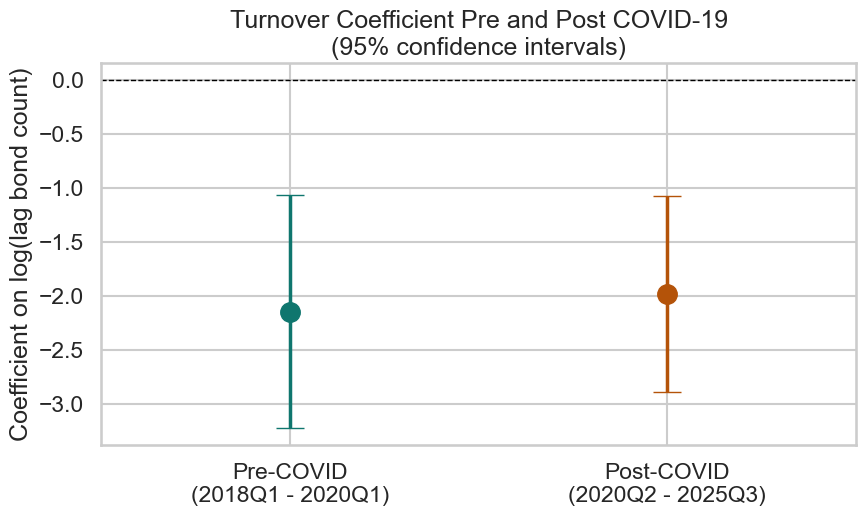

In [8]:
# Visualise the DiD result: turnover effect pre vs post COVID
labels = ["Pre-COVID\n(2018Q1 - 2020Q1)", "Post-COVID\n(2020Q2 - 2025Q3)"]
estimates = [pre, post]
se_pre_only = se_pre
# SE for post = sqrt(Var(pre) + Var(interact) + 2*Cov)
cov_matrix = m5.cov
var_pre = cov_matrix.loc["lag_log_bond_count", "lag_log_bond_count"]
var_int = cov_matrix.loc["lag_log_bond_count:post_covid", "lag_log_bond_count:post_covid"]
cov_pi = cov_matrix.loc["lag_log_bond_count", "lag_log_bond_count:post_covid"]
se_post = np.sqrt(var_pre + var_int + 2 * cov_pi)
ses = [se_pre_only, se_post]
ci_lo = [c - 1.96 * s for c, s in zip(estimates, ses)]
ci_hi = [c + 1.96 * s for c, s in zip(estimates, ses)]

fig, ax = plt.subplots(figsize=(9, 5.5))
colors = ["#0F766E", "#B45309"]
for i, (lbl, est, lo, hi, col) in enumerate(zip(labels, estimates, ci_lo, ci_hi, colors)):
    ax.errorbar(i, est, yerr=[[est - lo], [hi - est]], fmt="o",
                color=col, markersize=14, capsize=10, linewidth=2.5)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Turnover Coefficient Pre and Post COVID-19\n(95% confidence intervals)")
ax.set_ylabel("Coefficient on log(lag bond count)")
ax.set_xlim(-0.5, 1.5)
plt.tight_layout()
plt.savefig("../outputs/did_coefficient_plot.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation - DiD Result

The pre-COVID coefficient is sharply negative (-2.14, t -4.9): in the 2018-2020 Q1 window, suburbs with higher turnover saw notably slower rent growth. The interaction term is small and positive (+0.16) but **not statistically distinguishable from zero**, meaning we cannot reject the hypothesis that the relationship was the same pre and post COVID.

Visually, the coefficient is similar in both periods, with overlapping confidence intervals. The COVID shock disrupted the *level* of rents (sharp drop in 2020-2021, sharp recovery from 2022) but did not appear to change the underlying within-suburb relationship between turnover and rent growth.

Caveats: this is a single-equation pre/post comparison. A more rigorous test would be a full event study with quarter-by-quarter interactions, which we leave for future work.

## 5. Heterogeneity - Inner Melbourne vs the Rest

Inner Melbourne suburbs have very different rental markets from outer suburbs: higher density, more apartments, more sensitivity to international student demand. We split the sample and re-estimate the preferred specification on each side.

In [9]:
inner_suburbs = analysis.loc[analysis["region"] == "Inner Melbourne", "suburb"].unique()
panel_inner = panel[panel.index.get_level_values("suburb").isin(inner_suburbs)]
panel_other = panel[~panel.index.get_level_values("suburb").isin(inner_suburbs)]

m_inner = PanelOLS.from_formula(
    "rent_growth ~ lag_log_bond_count + log_lag_median_rent + EntityEffects + TimeEffects",
    data=panel_inner,
).fit(cov_type="clustered", cluster_entity=True)

m_other = PanelOLS.from_formula(
    "rent_growth ~ lag_log_bond_count + log_lag_median_rent + EntityEffects + TimeEffects",
    data=panel_other,
).fit(cov_type="clustered", cluster_entity=True)

het_table = pd.DataFrame({
    "": ["Inner Melbourne", "Rest of Melbourne"],
    "beta": [m_inner.params["lag_log_bond_count"], m_other.params["lag_log_bond_count"]],
    "SE": [m_inner.std_errors["lag_log_bond_count"], m_other.std_errors["lag_log_bond_count"]],
    "t": [m_inner.tstats["lag_log_bond_count"], m_other.tstats["lag_log_bond_count"]],
    "N obs": [int(m_inner.nobs), int(m_other.nobs)],
    "N suburbs": [int(m_inner.entity_info["total"]), int(m_other.entity_info["total"])],
}).set_index("")
het_table = het_table.round(3)
print("Table 3: Heterogeneity by Region")
print("Dependent variable: rent growth (%); model includes suburb FE, quarter FE, log(lag rent)")
print("=" * 80)
het_table

Table 3: Heterogeneity by Region
Dependent variable: rent growth (%); model includes suburb FE, quarter FE, log(lag rent)


,beta,SE,t,N obs,N suburbs
,,,,,
Inner Melbourne,0.962,0.828,1.161,660,22
Rest of Melbourne,-2.155,0.471,-4.572,2640,88


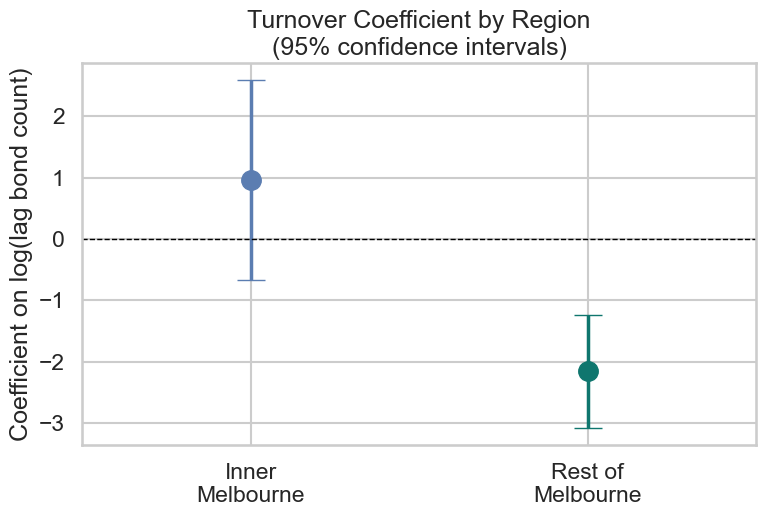

In [10]:
# Heterogeneity coefficient plot
labels = ["Inner\nMelbourne", "Rest of\nMelbourne"]
ests = [m_inner.params["lag_log_bond_count"], m_other.params["lag_log_bond_count"]]
ses = [m_inner.std_errors["lag_log_bond_count"], m_other.std_errors["lag_log_bond_count"]]
ci_lo = [c - 1.96 * s for c, s in zip(ests, ses)]
ci_hi = [c + 1.96 * s for c, s in zip(ests, ses)]

fig, ax = plt.subplots(figsize=(8, 5.5))
for i, (lbl, est, lo, hi) in enumerate(zip(labels, ests, ci_lo, ci_hi)):
    color = "#5B7DB1" if i == 0 else "#0F766E"
    ax.errorbar(i, est, yerr=[[est - lo], [hi - est]], fmt="o",
                color=color, markersize=14, capsize=10, linewidth=2.5)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Turnover Coefficient by Region\n(95% confidence intervals)")
ax.set_ylabel("Coefficient on log(lag bond count)")
ax.set_xlim(-0.5, 1.5)
plt.tight_layout()
plt.savefig("../outputs/heterogeneity_plot.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation - Heterogeneity

The negative within-suburb relationship between turnover and rent growth is concentrated in the **Rest of Melbourne** (mostly middle and outer suburbs): coefficient around -2.2, highly significant. In **Inner Melbourne**, the coefficient is small, positive, and not statistically distinguishable from zero, although the inner sample is much smaller (22 suburbs x 30 quarters = 660 obs).

An economic reading: in middle and outer suburbs, where many properties are houses and the rental stock turns over more slowly, an unusually high turnover quarter may signal an over-supplied local market that subsequently sees softer rent growth. In Inner Melbourne, where dense apartment markets churn rapidly under any conditions, turnover may be a less informative signal of market slack.

## 6. Discussion

### What we estimate

After controlling for suburb fixed effects, quarter fixed effects, and the lagged rent level, a 1% higher lagged bond-lodgement count in a Melbourne suburb is associated with about 0.019 percentage points lower rent growth in the subsequent quarter (Table 1, column 4). The relationship is concentrated in middle and outer suburbs and appears stable across the COVID period.

### What we cannot conclude

1. **This is not a causal estimate of the effect of vacancy on rent.** Bond-lodgement counts measure rental market *turnover* (the flow of new tenancies), not vacancy (the stock of empty properties). A high turnover quarter could reflect lots of new supply hitting the market (which would lower rents) or strong demand absorbing existing supply (which would raise rents) - we cannot separate the two.
2. **Reverse causality is possible.** Rents could affect turnover (high rents push tenants to move, generating new bonds) as much as turnover affects rents. We use the lagged regressor to mitigate the simultaneity, but this is a partial fix.
3. **Omitted variables remain.** Suburb FE absorbs everything time-invariant about a suburb. Quarter FE absorbs everything common across suburbs in a quarter. But suburb-specific time-varying shocks (a new development opening, a school zone change, a local employment shift) are still in the residual.

### Why these results are still useful

Even if we cannot claim a clean causal effect, the estimates establish a *conditional pattern* in Melbourne's rental market: within the same suburb, controlling for its rent level and for common time shocks, quarters of unusually high turnover are followed by slightly weaker rent growth. The pattern is robust across specifications (it survives adding quarter FE and the rent control), it is concentrated in suburbs where the dynamic is most plausible (middle and outer), and it is large enough to be economically meaningful.

### Functional form choices made along the way

- **log(bond_count)** rather than levels: bond counts span two orders of magnitude across suburbs (38 to 17,354), and the log gives the coefficient a percentage-change interpretation as in any log-linear specification (Lecture 7).
- **log(lag_median_rent)** as the rent control: rents are right-skewed; the log normalises the distribution and gives an elasticity-style coefficient.
- **Lagged rather than contemporaneous turnover**: reduces simultaneity bias from contemporaneous shocks.
- **Cluster-robust SEs at the suburb level**: standard practice for panel data where errors are likely correlated within suburbs across time.

## 7. Limitations

1. **Bond turnover is an imperfect proxy for vacancy.** SQM Research's commercial pricing for the proper variable was approximately $5,000 AUD; Monash Library does not subscribe to a residential property database; academic-access requests to RoZetta Institute went unanswered before submission. The cleaning pipeline (`code/01_clean_data.py`) is wired to merge SQM data automatically if it later becomes available.
2. **Moving annual smoothing.** Both rent and bond counts are 4-quarter moving averages, which dampens the visibility of sharp shocks. We chose not to undo this smoothing in order to keep the variables comparable to the published DFFH series.
3. **Quarterly frequency.** The DFFH source is quarterly; we cannot identify within-quarter dynamics. A monthly series (which SQM provides) would allow a tighter event-study around the COVID shock.
4. **Single Australian city.** Findings here cannot be generalised to Sydney, Brisbane, or regional rental markets - each has its own institutional features.
5. **Short panel.** Thirty quarters is a usable but not generous time dimension for FE inference; cluster-robust SEs at the suburb level partially address this.

## 8. Conclusion

Using a panel of 110 Melbourne suburbs over 30 quarters (2018-2025) and the new bond-lodgement turnover variable as a free substitute for the unavailable vacancy data, we find that within-suburb variation in lagged turnover is negatively associated with subsequent rent growth, particularly in middle and outer Melbourne. The relationship survives controlling for time-invariant suburb characteristics, common time shocks, and the lagged rent level - and it is stable across the COVID-era structural break.

This is a conditional association rather than a causal estimate, and the substitution of turnover for vacancy is a non-trivial concession to data availability. With access to suburb-level vacancy data, the same panel design could be re-estimated cleanly. A natural next step is to seek free academic access to CoreLogic / RP Data via RoZetta Institute and re-run the regressions on the proper variable.